# Workshop Notebook #1 - MIRI Photometry Solutions

## Author: Taylor Bell (ESA/AURA for STScI)

Run the Setup.ipynb notebook to download the data. The setup notebook needs to just be run **once**.

# Installing Eureka! on your computer

You should first follow the installation instructions at https://eurekadocs.readthedocs.io/en/latest/installation.html to install Eureka! on your computer.

---
# Setting up the notebook

The first step is to setup the notebook and environment.

We'll first import Eureka! along with some other useful packages.

In [1]:
import eureka
import os
import numpy as np

Next, we need to choose a short, meaningful label (without spaces) that describes the data we're currently working on. For simplicity, we will just set `eventlabel = 'miri_photometry'`. This same event label should be used throughout all stages.

In [2]:
eventlabel = 'miri_photometry'

To save time, we've also provided _rateints files produced from Stage 1 which would otherwise take 15+ minutes to produce (the exact runtime depends on your CPU and on whether multiple CPU threads are used). If you want to use those cached _rateints files, set `use_cached_s1` to `True`, otherwise set it to `False`.

In [3]:
use_cached_s1 = True

---
# Stage 1: jwst Pipeline (Eureka!'s wrapper)

## Setting the Stage 1 "Eureka! Control File"

Some of the parameters that might be worth varying are as follows:

* `maximum_cores`: If want to limit the CPU usage of the stage, for example if you are running your data reduction on a shared sherver, you can set this to an integer number of cores or one of `'none'` (for single-threaded operations), `'quarter'`, `'half'`, or `'all'`.
* `skip_firstframe`: This might be worth changing between `True`/`False`. The MIRI detectors show marked persistence effects, which manifest as deviations from linearity at the start of each ramp. To mitigate the effect of persistence on the measured countrates, this step flags the first group in every integration, instructing the pipeline to ignore the first group when fitting the ramps. For TSOs, this step is skipped by default (`skip_firstframe = True`), which does not remove the first frame. In theory it'd be best to set this to `False` (which removes the first group which is known to be noisy), but for integrations with small numbers of groups it might be worth setting to `True`. It is hard to say for sure without experimenting.
* `skip_lastframe`: This might be worth changing between `True`/`False`. In the case of MIRI detectors, the array is reset during the last frame read in each integration, which results in a reduced level of accumulated counts in the last frame. By default, the pipeline applies this step to all MIRI data (`skip_firstframe = False`), flagging the last group in every integration as bad (as long as the number of groups per integration is greater than 2). This step is strongly recommended for TSOs (`skip_firstframe = False`), given that the last frame effect has been shown to vary from integration to integration. However, for integrations with a very small number of groups it might be worth setting to `True`. It is hard to say for sure without experimenting.
* `skip_emicorr`: It could be worth changing this between `True`/`False`, but this likely won't have a very large impact. MIRI subarrays suffer from electromagnetic interference (EMI) noise patterns in the raw data that imprint periodic noise into each frame image, with the effect particularly apparent in the case of short ramps, which is typical of most MIRI TSOs. There are two algorithms that the pipeline can select from when applying this step: 'sequential' (the default) fits the EMI in the residuals from ramp fits, while 'joint' carries out a simultaneous fit to the ramps and EMI noise using a reference waveform for the EMI oscillations. The 'sequential' method typically requires 10 or more groups per integration for a reliable fit, while the 'joint' method has been demonstrated to successfully fit EMI noise for any ramp length. In practice, the background subtraction we'll do in Stage 3 ends up providing most of the benefits of this step, so it may not always be worth running. By default, the Eureka! pipeline skips this step (`skip_emicorr = True`), while the jwst pipeline's default is to run the step (`skip_emicorr = False`).
* `skip_rscd`: It could be worth changing this between `True`/`False`. This step mitigates nonlinear behavior at the beginning of each ramp due to transient effects on the detector after every reset. While the exact causes of these effects are not fully understood, the severity of the nonlinearity scales with increasing signal, suggesting a type of persistence on the detectors. Currently, this step in the pipeline flags the first N groups at the beginning of all 2nd and higher integrations, where N is fixed to different values for different observing modes (e.g., N=4 in the case of MIRI LRS slitless TSOs). Due to the short ramps of most TSOs, this step is skipped by default (`skip_rscd = True`), as the flagging of a significant fraction of each ramp results in a steep reduction in the signal-to-noise ratio. However, if the TSO includes relatively large-amplitude features (e.g., exoplanet transits), and if the ramps are long enough to allow for the `rscd` step to be run, turning on this step can ameliorate biases in the relative flux levels due to the signal-dependent nonlinearity effects across the time series.
* `skip_jump` & `jump_rejection_thr shold`: The `jump` step flags outliers in the ramps due to cosmic ray hits. The algorithm uses an iterative process that examines the countrates between sequential pairs of groups and applies a sigma-clipping filter to flag groups that yield anomalously large countrates. The default sigma threshold used by the pipeline is `4.0`, though in practice, this settings results in a large number of false positives. Users are recommended to adjust the threshold to higher values (e.g., `8`-`10`) or skip this step altogether in favor of outlier masking at later stages of the data processing workflow. The threshold within Eureka! can be set with the `jump_rejection_threshold` parameter, and the step can be skipped by setting `skip_jump` to `True`.
* `skip_dark_current`: By default this step is run for MIRI TSO observations and is likely best left to run (set the skip parameter to `False`), but it's possible better results could be obtained by experimenting with setting the skip parameter to `True`.
* `skip_refpix`: By default this steps is run for MIRI TSO observations that are taken with the FULL array. For subarrays, including the LRS Slitless subarray, this step is automatically skpped and will not run even if set to `False`. It is possible better results could be obtained by experimenting with setting the skip parameters to `True` for data read with the FULL array.

For more information on the options available in Stage 1, visit https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-1

To change a parameter in the metadata class after it has been read-in, you can do something like the following:
```
s1_meta.jump_rejection_threshold = 10.0
```

In [4]:
s1_ecf_contents = f"""
# Eureka! Control File for Stage 1: Detector Processing

# Stage 1 Documentation: https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-1

suffix                    uncal

pmap                      1364         # Setting a fixed pmap value to ensure consistency in reductions

maximum_cores             'all'        # Options are 'none', 'quarter', 'half', 'all', or any integer

# Pipeline stages
skip_emicorr              True         #### Might be worth experimenting with turning on/off
skip_saturation           False
skip_firstframe           False        #### Might be worth experimenting with turning on/off
skip_lastframe            False        #### Might be worth experimenting with turning on/off
skip_reset                False
skip_linearity            False
skip_rscd                 False        #### Might be worth experimenting with turning on/off
skip_dark_current         False        #### Might be worth experimenting with turning on/off
skip_refpix               False        #### Might be worth experimenting with turning on/off
skip_jump                 False
skip_clean_flicker_noise  True         #### Might be worth experimenting with turning on/off

#Pipeline stages parameters
jump_rejection_threshold  8.0          #### Might be worth experimenting with different values

# Diagnostics
isplots_S1                3
nplots                    5
hide_plots                False
verbose                   True

# Project directory
topdir                    ../miri_photometry/

# Directories relative to project dir
inputdir                  Uncalibrated
outputdir                 Stage1
"""

# This will save the ECF as a file that the next cell can read-in
with open(f'./S1_{eventlabel}.ecf', 'w') as f:
    f.write(s1_ecf_contents)

## Running Stage 1

In [5]:
if use_cached_s1 or not os.path.exists('../miri_photometry/Stage1/S1_2025-04-21_miri_photometry_run1'):
    s1_meta = eureka.S1_detector_processing.s1_process.rampfitJWST(eventlabel, ecf_path='./')

CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/home/tbell/miniconda3/envs/eureka_rwddt2/lib/python3.11/site-packages/jwst-1.18.0.dist-info)



Starting Stage 1 Processing
Input directory: ../miri_photometry/Uncalibrated/
  Found 10 data file(s) ending in uncal.fits
Output directory: ../miri_photometry/Stage1/S1_2025-04-21_miri_photometry_run1/
Copying S1 control file
Starting file 1 of 10: jw01177011001_03101_00001-seg001_mirimage_uncal.fits


2025-04-21 20:17:26,148 - stpipe.EurekaS1Pipeline - INFO - EurekaS1Pipeline instance created.
2025-04-21 20:17:26,149 - stpipe.EurekaS1Pipeline.group_scale - INFO - GroupScaleStep instance created.
2025-04-21 20:17:26,150 - stpipe.EurekaS1Pipeline.dq_init - INFO - DQInitStep instance created.
2025-04-21 20:17:26,151 - stpipe.EurekaS1Pipeline.emicorr - INFO - EmiCorrStep instance created.
2025-04-21 20:17:26,152 - stpipe.EurekaS1Pipeline.saturation - INFO - SaturationStep instance created.
2025-04-21 20:17:26,153 - stpipe.EurekaS1Pipeline.ipc - INFO - IPCStep instance created.
2025-04-21 20:17:26,153 - stpipe.EurekaS1Pipeline.superbias - INFO - SuperBiasStep instance created.
2025-04-21 20:17:26,154 - stpipe.EurekaS1Pipeline.refpix - INFO - RefPixStep instance created.
2025-04-21 20:17:26,155 - stpipe.EurekaS1Pipeline.rscd - INFO - RscdStep instance created.
2025-04-21 20:17:26,156 - stpipe.EurekaS1Pipeline.firstframe - INFO - FirstFrameStep instance created.
2025-04-21 20:17:26,156 - s

Starting file 2 of 10: jw01177011001_03101_00001-seg002_mirimage_uncal.fits


2025-04-21 20:19:13,961 - stpipe.EurekaS1Pipeline - INFO - EurekaS1Pipeline instance created.
2025-04-21 20:19:13,962 - stpipe.EurekaS1Pipeline.group_scale - INFO - GroupScaleStep instance created.
2025-04-21 20:19:13,963 - stpipe.EurekaS1Pipeline.dq_init - INFO - DQInitStep instance created.
2025-04-21 20:19:13,964 - stpipe.EurekaS1Pipeline.emicorr - INFO - EmiCorrStep instance created.
2025-04-21 20:19:13,964 - stpipe.EurekaS1Pipeline.saturation - INFO - SaturationStep instance created.
2025-04-21 20:19:13,965 - stpipe.EurekaS1Pipeline.ipc - INFO - IPCStep instance created.
2025-04-21 20:19:13,966 - stpipe.EurekaS1Pipeline.superbias - INFO - SuperBiasStep instance created.
2025-04-21 20:19:13,967 - stpipe.EurekaS1Pipeline.refpix - INFO - RefPixStep instance created.
2025-04-21 20:19:13,968 - stpipe.EurekaS1Pipeline.rscd - INFO - RscdStep instance created.
2025-04-21 20:19:13,968 - stpipe.EurekaS1Pipeline.firstframe - INFO - FirstFrameStep instance created.
2025-04-21 20:19:13,969 - s

...

Starting file 9 of 10: jw01177011001_03101_00001-seg009_mirimage_uncal.fits


2025-04-21 20:28:27,811 - stpipe.EurekaS1Pipeline - INFO - EurekaS1Pipeline instance created.
2025-04-21 20:28:27,811 - stpipe.EurekaS1Pipeline.group_scale - INFO - GroupScaleStep instance created.
2025-04-21 20:28:27,812 - stpipe.EurekaS1Pipeline.dq_init - INFO - DQInitStep instance created.
2025-04-21 20:28:27,813 - stpipe.EurekaS1Pipeline.emicorr - INFO - EmiCorrStep instance created.
2025-04-21 20:28:27,814 - stpipe.EurekaS1Pipeline.saturation - INFO - SaturationStep instance created.
2025-04-21 20:28:27,814 - stpipe.EurekaS1Pipeline.ipc - INFO - IPCStep instance created.
2025-04-21 20:28:27,815 - stpipe.EurekaS1Pipeline.superbias - INFO - SuperBiasStep instance created.
2025-04-21 20:28:27,816 - stpipe.EurekaS1Pipeline.refpix - INFO - RefPixStep instance created.
2025-04-21 20:28:27,817 - stpipe.EurekaS1Pipeline.rscd - INFO - RscdStep instance created.
2025-04-21 20:28:27,818 - stpipe.EurekaS1Pipeline.firstframe - INFO - FirstFrameStep instance created.
2025-04-21 20:28:27,818 - s

Starting file 10 of 10: jw01177011001_03101_00001-seg010_mirimage_uncal.fits


2025-04-21 20:29:42,174 - stpipe.EurekaS1Pipeline - INFO - EurekaS1Pipeline instance created.
2025-04-21 20:29:42,175 - stpipe.EurekaS1Pipeline.group_scale - INFO - GroupScaleStep instance created.
2025-04-21 20:29:42,176 - stpipe.EurekaS1Pipeline.dq_init - INFO - DQInitStep instance created.
2025-04-21 20:29:42,177 - stpipe.EurekaS1Pipeline.emicorr - INFO - EmiCorrStep instance created.
2025-04-21 20:29:42,177 - stpipe.EurekaS1Pipeline.saturation - INFO - SaturationStep instance created.
2025-04-21 20:29:42,178 - stpipe.EurekaS1Pipeline.ipc - INFO - IPCStep instance created.
2025-04-21 20:29:42,179 - stpipe.EurekaS1Pipeline.superbias - INFO - SuperBiasStep instance created.
2025-04-21 20:29:42,180 - stpipe.EurekaS1Pipeline.refpix - INFO - RefPixStep instance created.
2025-04-21 20:29:42,181 - stpipe.EurekaS1Pipeline.rscd - INFO - RscdStep instance created.
2025-04-21 20:29:42,182 - stpipe.EurekaS1Pipeline.firstframe - INFO - FirstFrameStep instance created.
2025-04-21 20:29:42,182 - s


Total time (min): 12.88
Saving Metadata


---
# Stage 2: jwst Pipeline (Eureka!'s wrapper)

## Setting up the Stage 2 "Eureka! Control File"

For MIRI TSO data, there is very little of importance in Stage 2. The main steps of note are:
* `assign_wcs`: This non-optional step is what assigns the RA and Dec solution to your photometry.
* `flat_field`: This step calibrates non-uniform illumination and response of different pixels. Given that JWST TSO data is typically extremely stable in position over time, this step often isn't very important for TSO data one way or the other as long as you aren't producing absolutely calibrated data.
* `photom`: This step converts the units of the images from the measurement units related to Data Numbers to physical units of MJy/sr. Since TSO data generally doesn't require absolutely calibrated fluxes, we normally skip this step (by setting `skip_photom` to `True`) for exoplanet data. This has the added advantage of more easily being able to estimate the uncertainties in the time series later on. However, if you want to produce an absolutely calibrated spectrum of the host star in order to compare the observed stellar flux with stellar models, then the `photom` step should be turned on.

In [6]:
s2_ecf_contents = f"""
# Eureka! Control File for Stage 2: Data Reduction

# Stage 2 Documentation: https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-2

suffix          rateints    # Data file suffix

pmap            1364        # Setting a fixed pmap value to ensure consistency in reductions

# Note: different instruments and modes will use different steps by default
skip_flat_field False       #### Might be worth experimenting with turning on/off
skip_photom     True        # Strongly recommended to skip (unless doing flux calibrated photometry) in order to get better uncertainties out of Stage 3.

# Diagnostics
hide_plots      False       # If True, plots will automatically be closed rather than popping up

# Project directory
topdir          ../miri_photometry/

# Directories relative to project dir
inputdir        Stage1
outputdir       Stage2
"""

# This will save the ECF as a file that the next cell can read-in
with open(f'./S2_{eventlabel}.ecf', 'w') as f:
    f.write(s2_ecf_contents)

## Running Stage 2

For these particular data, running Stage 2 should take ~2 minutes, though the exact runtime depends on your specific CPU

In [7]:
s2_meta = eureka.S2_calibrations.s2_calibrate.calibrateJWST(eventlabel, ecf_path='./')


Starting Stage 2 Reduction
Input directory: ../miri_photometry/Stage1/S1_2025-04-21_miri_photometry_run1/
  Found 10 data file(s) ending in rateints.fits
Output directory: ../miri_photometry/Stage2/S2_2025-04-21_miri_photometry_run1/
Copying S2 control file


2025-04-21 20:30:18,206 - stpipe.EurekaImage2Pipeline - INFO - EurekaImage2Pipeline instance created.
2025-04-21 20:30:18,207 - stpipe.EurekaImage2Pipeline.bkg_subtract - INFO - BackgroundStep instance created.
2025-04-21 20:30:18,208 - stpipe.EurekaImage2Pipeline.assign_wcs - INFO - AssignWcsStep instance created.
2025-04-21 20:30:18,209 - stpipe.EurekaImage2Pipeline.flat_field - INFO - FlatFieldStep instance created.
2025-04-21 20:30:18,210 - stpipe.EurekaImage2Pipeline.photom - INFO - PhotomStep instance created.
2025-04-21 20:30:18,211 - stpipe.EurekaImage2Pipeline.resample - INFO - ResampleStep instance created.


Starting file 1 of 10
Running the Image2Pipeline



2025-04-21 20:30:18,228 - stpipe - WARNING - /home/tbell/miniconda3/envs/eureka_rwddt2/lib/python3.11/site-packages/eureka/S2_calibrations/s2_calibrate.py:349: UserWarning: Step.__call__ is deprecated. It is equivalent to Step.run and is not recommended. See https://jwst-pipeline.readthedocs.io/en/latest/jwst/user_documentation/running_pipeline_python.html#advanced-use-pipeline-run-vs-pipeline-call for more details.
  self(filename)

2025-04-21 20:30:18,229 - stpipe - WARNING - /home/tbell/miniconda3/envs/eureka_rwddt2/lib/python3.11/site-packages/stpipe/step.py:580: UserWarning: Step.__call__ is deprecated. It is equivalent to Step.run and is not recommended.
  warnings.warn(

2025-04-21 20:30:18,380 - stpipe.EurekaImage2Pipeline - INFO - Step EurekaImage2Pipeline running with args ('../miri_photometry/Stage1/S1_2025-04-21_miri_photometry_run1/jw01177011001_03101_00001-seg001_mirimage_rateints.fits',).
2025-04-21 20:30:18,386 - stpipe.EurekaImage2Pipeline - INFO - Step EurekaImage2Pip

Starting file 2 of 10
Running the Image2Pipeline



...

Starting file 9 of 10
Running the Image2Pipeline



2025-04-21 20:31:39,883 - stpipe - WARNING - /home/tbell/miniconda3/envs/eureka_rwddt2/lib/python3.11/site-packages/eureka/S2_calibrations/s2_calibrate.py:349: UserWarning: Step.__call__ is deprecated. It is equivalent to Step.run and is not recommended. See https://jwst-pipeline.readthedocs.io/en/latest/jwst/user_documentation/running_pipeline_python.html#advanced-use-pipeline-run-vs-pipeline-call for more details.
  self(filename)

2025-04-21 20:31:39,883 - stpipe - WARNING - /home/tbell/miniconda3/envs/eureka_rwddt2/lib/python3.11/site-packages/stpipe/step.py:580: UserWarning: Step.__call__ is deprecated. It is equivalent to Step.run and is not recommended.
  warnings.warn(

2025-04-21 20:31:40,029 - stpipe.EurekaImage2Pipeline - INFO - Step EurekaImage2Pipeline running with args ('../miri_photometry/Stage1/S1_2025-04-21_miri_photometry_run1/jw01177011001_03101_00001-seg009_mirimage_rateints.fits',).
2025-04-21 20:31:40,037 - stpipe.EurekaImage2Pipeline - INFO - Step EurekaImage2Pip

Starting file 10 of 10
Running the Image2Pipeline



2025-04-21 20:31:50,000 - stpipe - WARNING - /home/tbell/miniconda3/envs/eureka_rwddt2/lib/python3.11/site-packages/eureka/S2_calibrations/s2_calibrate.py:349: UserWarning: Step.__call__ is deprecated. It is equivalent to Step.run and is not recommended. See https://jwst-pipeline.readthedocs.io/en/latest/jwst/user_documentation/running_pipeline_python.html#advanced-use-pipeline-run-vs-pipeline-call for more details.
  self(filename)

2025-04-21 20:31:50,001 - stpipe - WARNING - /home/tbell/miniconda3/envs/eureka_rwddt2/lib/python3.11/site-packages/stpipe/step.py:580: UserWarning: Step.__call__ is deprecated. It is equivalent to Step.run and is not recommended.
  warnings.warn(

2025-04-21 20:31:50,156 - stpipe.EurekaImage2Pipeline - INFO - Step EurekaImage2Pipeline running with args ('../miri_photometry/Stage1/S1_2025-04-21_miri_photometry_run1/jw01177011001_03101_00001-seg010_mirimage_rateints.fits',).
2025-04-21 20:31:50,163 - stpipe.EurekaImage2Pipeline - INFO - Step EurekaImage2Pip

Saving Metadata

Total time (min): 1.61


---
# Stage 3: Eureka!

### Setting the Stage 3 "Eureka! Control File" (ECF)

**This determines what will happen during Stage 3**

The most important parameters and their recommended settings are described below, but more context can be found on the [Eureka! documentation website](https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-3).

1.   Set `ncpu` to the number of CPU threads you want to use. If set to `1` no multiprocessing will be done, and this parameter can be increased to ~2x your CPU core count for faster runs.
2.   Set both `ywindow` and `xwindow` to `None` - this will crop a 150x150 pixel box around the approximate centroid (since the MIRI full frame images are very large and it is generally helpful and faster to zoom-in on the science target).
3.   Set `dqmask` to `True` to mask known-bad pixels.

4.   Set `ff_outlier` to `True`. If set to `True`, this step would perform sigma clipping along the entire time axis for the entire frame, while this is only done to the background pixels if `ff_outlier` is set to `False`. Setting `ff_outlier` to `True` is only really safe for observations of shallow eclipses where the sigma-clipping algorithm is unlikely to confuse an astrophysical signal as being an outlier.
5.   Set `bg_thresh` (background area outlier threshold) values to `[5,5]` to do two iterations of 5-sigma clipping along the time axis to remove artifacts like cosmic rays.
6.   Set `interp_method` to `linear`. This controls how bad pixels are replaced through interpolation, with options `None` (if no interpolation should be performed), `linear`, `nearest`, and `cubic`.

7.   Set `centroid_method` to `mgmc` - this controls the photometric centroiding algoirthm, with options of `fgc` or `mgmc`.
8.   Set `ctr_guess` to `fits` to use the approximate centroid position from the FITS header as the starting guess for the centroiding algorithm.
9.   Set `ctr_cutout_size` to `10`. This is used to make a temporary smaller subarray centered on the initial centroid position guess in order to produce a better centroid position that is less biased by background levels and/or nearby stars.
10.   Set `centroid_tech` to `com` to use the center-of-mass option which generally provides precise and stable centroid positions for TSO photometry. Other options are `1dg` and `2dg` which fit 1D or 2D Gaussians to the images to estimate the centroid.

11.   Set `phot_method` to `photutils` to use the photutils aperture photometric extraction algorithm. Other options include `poet` (aperture photometry using code from POET), or `optimal` (for optimal photometric extraction)
12.   Set `aperture_edge` to `exact` to weight each pixel by the fractional area that lies within the aperture. The other option is `center` which only includes pixels if their center lies within the aperture.
13.   Set `aperture_shape` to `circle` to use a circular photometric aperture. If `phot_method` is `photutils` or `optimal`, the options are `circle`, `ellipse`, or `rectangle`. If `phot_utils` is `poet`, the options are `circle` or `hexagon`. This parameter is used to set both the object aperture shape and the sky annulus shape
14.   Set `moving_centroid` to `False` to keep the aperture fixed on the median centroid location. If set to `True`, the aperture would track the moving centroid.
15.   Set `skip_apphot_bg` to `False` to perform background subtraction using a background annulus. If set to `False`, skips the background subtraction during the aperture photometry step.
16.   Set `photap` to `5` to set the size of photometry aperture radius in pixels.
17.   Set `skyin` to `16` to set the radius of the inner sky annulus edge, in pixels.
18.   Set `skywidth` to `32` to set the width of the sky annulus, in pixels.

19.  Set `isplots_S3` to `4` to get lots of useful diagnostic figures (increase this to 5 if you need more plots to investigate problems).
20.  Set `nplots` to `5` to make repetitive figures only for the first 5 integrations (you can increase this as needed if you want more figures for troubleshooting)
21.  Set `hide_plots` to `False` so that the figures pop up in this notebook as they're made (set to `True` if you're not running the code in a notebook, otherwise you'll have a lot of windows popping up).
22.  Set `verbose` to `True` so you get lots of useful information printed out.
23.  Set `topdir` to the same value as you used in Stage 2

In [8]:
s3_ecf_contents = f"""
# Eureka! Control File for Stage 3: Data Reduction

# Stage 3 Documentation: https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-3

ncpu            16
nfiles          200
max_memory      1.5
indep_batches   False       # Independently treat each batch of files? Strongly recommended to leave this as False unless you have a clear reason to set it to True.
suffix          calints

calibrated_spectra  False   # Set True to generate flux-calibrated spectra/photometry in mJy
                            # Set False to convert to electrons
pmap            1364

# Subarray region of interest
ywindow         None        # Vertical axis as seen in DS9
xwindow         None        # Horizontal axis as seen in DS9
dqmask          True

# Background parameters
ff_outlier      True        # Set False to use only background region (recommended for deep transits)
                            # Set True to use full frame (works well for shallow transits/eclipses)
bg_thresh       [5,5]
interp_method   linear      # Interpolate bad pixels. Options: None (if no interpolation should be performed), linear, nearest, cubic

# Centroiding parameters
centroid_method mgmc        # Method used for centroiding. Options: mgmc, fgc
ctr_guess       fits        # Initial guess of centroid position. If None, will first perform centroiding on whole frame (can sometimes fail)
ctr_cutout_size 10          # Cutoff size all around the centroid after the coarse centroid calculation or first centroid guess when using the mgmc method.
centroid_tech   com         # (mgmc method param) Technique used for centroiding. Options: com, 1dg, 2dg
gauss_frame     15          # (mgmc method param) Half-width away from second centroid guess to include in centroiding map for gaussian widths. Recommend ~15 for MIRI photometry.

# Photometric extraction parameters
phot_method     photutils   # photutils (aperture photometry using photutils), poet (aperture photometry using code from POET), or optimal (for optimal photometric extraction)
aperture_edge   exact       # center (pixel is included only if its center lies within the aperture), or exact (pixel is weighted by the fractional area that lies within the aperture)
aperture_shape  circle      # If phot_method is photutils or optimal: circle, ellipse, or rectangle. If phot_utils is poet: circle or hexagon. Used to set both the object aperture shape and the sky annulus shape
moving_centroid False       # Boolean: False if the aperture should stay fixed on the median centroid location (recommended), or True if the aperture should track the moving centroid
skip_apphot_bg  False       # Skips the background subtraction during the aperture photometry step
photap          5           # Size of photometry aperture radius in pixels
skyin           16          # Inner sky annulus edge, in pixels
skywidth        32          # Width of the sky annulus, in pixels

# Diagnostics
isplots_S3      4           # Generate few (1), some (3), or many (5) figures (Options: 1 - 5)
nplots          1           # How many of each type of figure do you want to make per file?
hide_plots      False       # If True, plots will automatically be closed rather than popping up
save_output     True        # Save outputs for use in S4
save_fluxdata   False       # Save FluxData outputs for debugging or use with other tools (can be quite large files)
verbose         True        # If True, more details will be printed about steps

# Project directory
topdir          ../miri_photometry/

# Directories relative to project dir
inputdir        Stage2
outputdir       Stage3
"""

# This will save the ECF as a file that the next cell can read-in
with open(f'./S3_{eventlabel}.ecf', 'w') as f:
    f.write(s3_ecf_contents)

### Running Eureka!'s Stage 3

The following cell will run Eureka!'s Stage 3 using the settings you defined above. Note that your ECF will be copied to your output folder, making it easy to remember how you produced those outputs hours, days, or years after you reduced the data.

This stage of Eureka! will take ~1 minute for these particular data.


Starting Stage 3 Reduction

Input directory: ../miri_photometry/Stage2/S2_2025-04-21_miri_photometry_run1/
  Found 10 data file(s) ending in calints.fits
Output directory: ../miri_photometry/Stage3/S3_2025-04-21_miri_photometry_run1/ap5_bg16_48/
Using ap=5, bg=16_48, expand=1
Copying S3 control file
Starting batch 1 of 1 with 10 files
  Reading file 10...
  Concatenating files...
  Masking NaNs/infs in data arrays...
    FLUX has 35087 NaNs/infs, which is 0.41% of all pixels.
    ERR has 35087 NaNs/infs, which is 0.41% of all pixels.
    V0 has 35087 NaNs/infs, which is 0.41% of all pixels.
  Converting from data numbers per second (DN/s) to electrons...
  Automatically getting reference files...
  Performing full frame outlier rejection...
    Flagged 0.007074% of pixels as bad.
  Computing clean median frame...


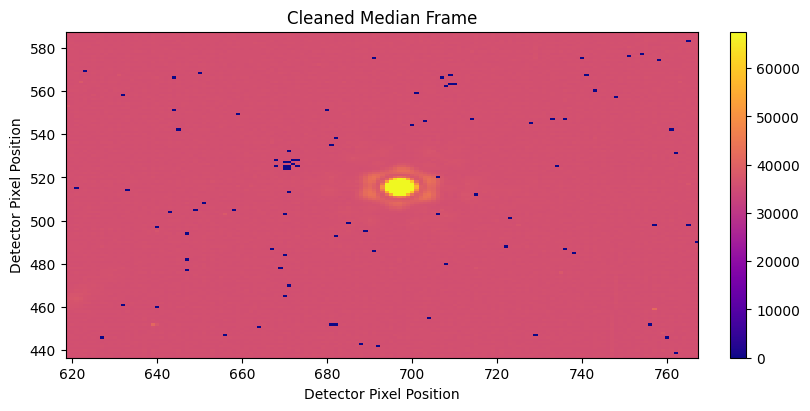

  Using approximate centroid position from FITS header for initial centroid estimate


  Interpolating masked values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 377/377 [00:11<00:00, 33.89it/s]


  Doing second round of mgmc centroiding...


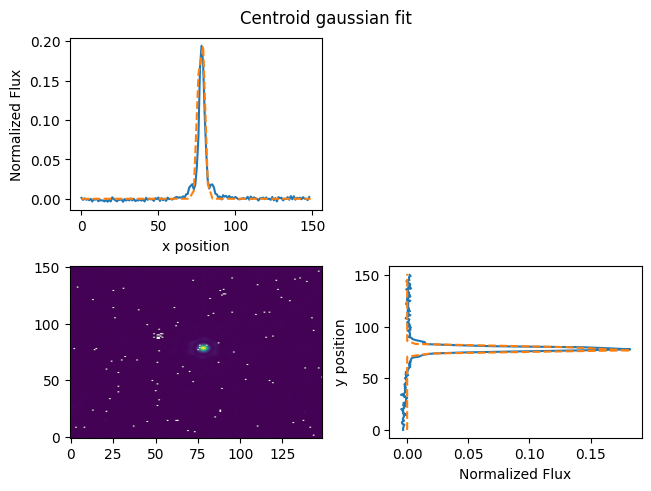

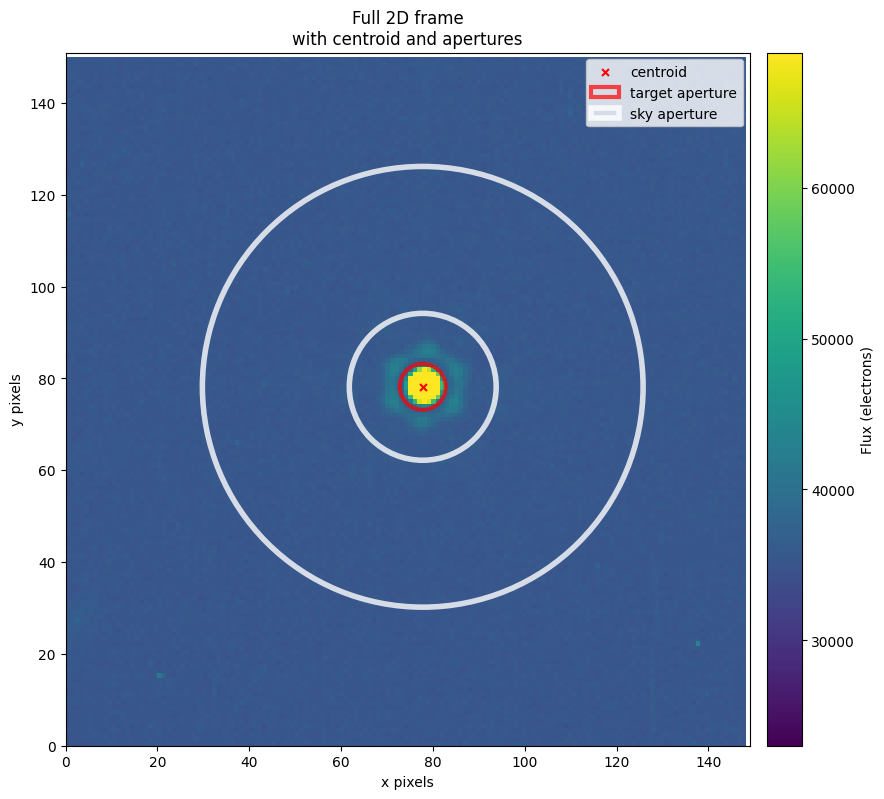

  Doing photometric extraction...


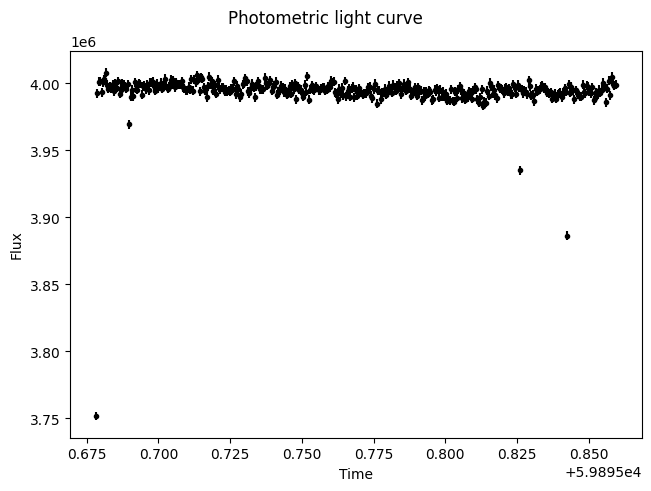

<Figure size 640x480 with 0 Axes>

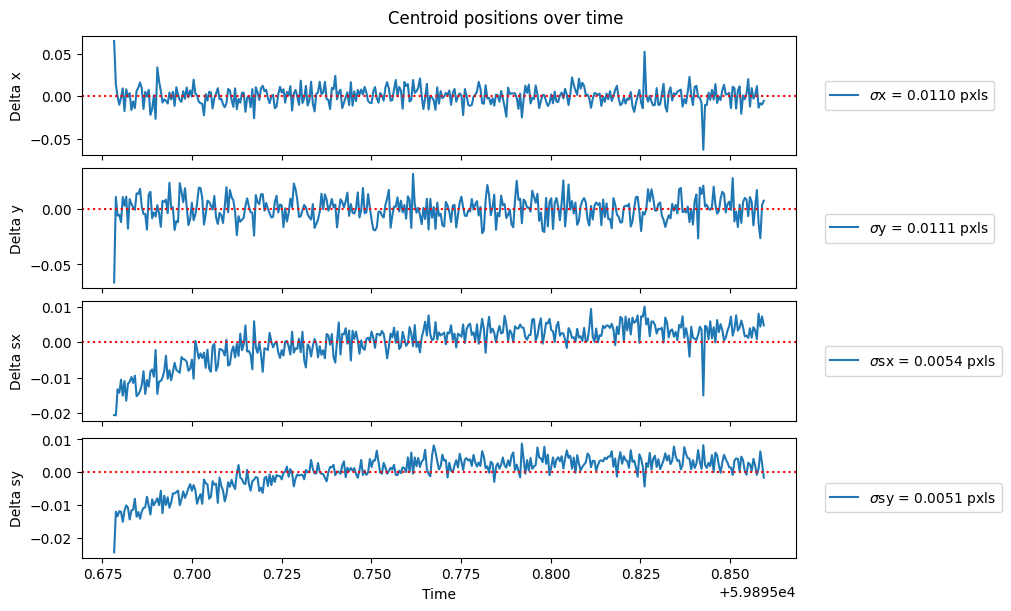

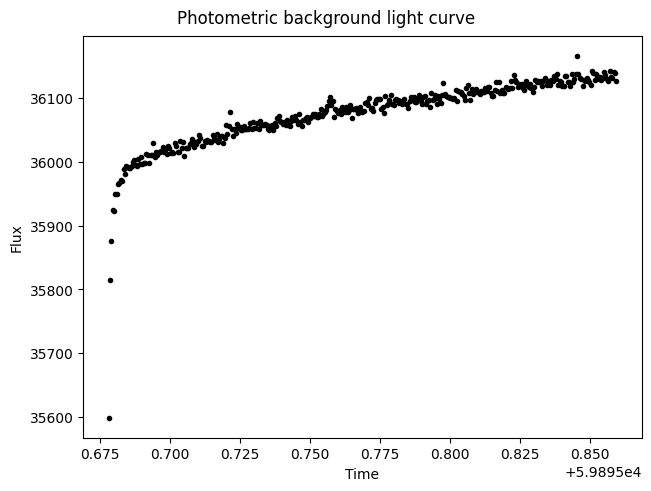

Stage 3 MAD = 834 ppm
Finished writing to ../miri_photometry/Stage3/S3_2025-04-21_miri_photometry_run1/ap5_bg16_48/S3_miri_photometry_ap5_bg16_48_SpecData.h5

Total time (min): 1.17


In [9]:
s3_spec, s3_meta = eureka.S3_data_reduction.s3_reduce.reduce(eventlabel, ecf_path='./')

---
# Stage 4: Eureka!

## Broadband lightcurve

### Setting the Stage 4 "Eureka! Control File" (ECF)

This determines what will happen during Stage 4

The most important parameters and their recommended settings are described below, but more context can be found on the [Eureka! documentation website](https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-4).


To sigma-clip outliers, we need to have a reference time-series against which we are comparing our observations. If we just took the whole time-series and sigma clipped compared to the median level of the observations, we may well sigma-clip the entire transit signal in cases where there is a strong transit. Instead, we use a [box-car](https://en.wikipedia.org/wiki/Boxcar_function) filter which acts as a [high-pass filter](https://en.wikipedia.org/wiki/High-pass_filter); this removes any low-frequency signals (e.g. transit ingress/egress, phase variations, linear trends in time) and leaves behind high-frequency noise (cosmic rays, HGA moves, etc.). The most important parameters that control this box-car clipping are `sigma` and `box_width`, but `boundary` and `fill_value` are also relevant parameters.

1.   Remove outliers along the time axis (e.g. cosmic rays) by setting `clip_binned` to `True` (basically always helpful). `clip_unbinned` is typically not helpful and should be set to `False`.
2.   Set `sigma` to a value low enough to clip any obviously errant points while ensuring you are not clipping an excessive number of points and not clipping the transit or eclipse's ingress/egress. For these particular data, something around `3.5` should do, but this is not a strict rule and will change for each different dataset. The focus here is to remove obviously errant points and not to clip a bunch of points.
3.   Set `box_width` to a value small enough to not sigma-clip the transit or eclipse's ingress/egress, while also not setting it so small that the smoothed copy of the signal is excessively noisy. For these particular data, something around `20` should do, but again this is not a strict rule and will change for each different dataset.
4.   Set `boundary` to `fill` as this typically results in reasonable behaviour at the start and end of the observations.
5.   Set `fill_value` to `mask` in order to mask the clipped outliers without replacement. This ensures you remove bad values without requiring you to replace the masked values with a guess as to the value the point should have (a potentially dangerous endeavour).


Finally, there are some plotting/logging controls you should adjust:

6.  Set `compute_ld` to `False`. Since we're working on an eclipse observation, there is no need to compute theoretical limb-darkening coefficients for the star. The other inputs related to computing limb-darkening coefficients can then safely be ignored.
7.  Set `isplots_S4` to `3` to get some useful diagnostic figures (increase this to 5 if you need more plots to investigate problems).
8.  Set `hide_plots` to `False` so that the figures pop up in this notebook as they're made (set to `True` if you're running the code in the terminal instead of a notebook, otherwise you'll have a lot of windows popping up).
9.  Set `verbose` to `True` so you get lots of useful information printed out.
10.  Set `topdir` to the same value as you used in Stage 3.
11.  Set `inputdir` to `Stage3`. If you end up running multiple version of Eureka!'s Stage 3, you can select the exact one you want as an input to Stage 4 by specifying the folder name in more detail (e.g. `Stage3/S3_2023-07-24_miri_run1`).
12.  Set `outputdir` to `Stage4`

In [10]:
s4_ecf_contents = f"""
# Eureka! Control File for Stage 4: Generate Lightcurves

# Stage 4 Documentation: https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-4

allapers        True    # Run S4 on all of the apertures considered in S3 Otherwise will use newest output in the inputdir

# Number of spectroscopic channels spread evenly over given wavelength range
nspecchan       1           # Number of spectroscopic channels spread evenly over given wavelength range. Set to None to leave the spectrum unbinned.
compute_white   False       # Also compute the white-light lightcurve

# Parameters for sigma clipping
clip_binned     True    # Whether or not sigma clipping should be performed on the binned 1D time series
sigma           3.5     # The number of sigmas a point must be from the rolling median to be considered an outlier
box_width       20      # The width of the box-car filter (used to calculated the rolling median) in units of number of data points
maxiters        20      # The number of iterations of sigma clipping that should be performed.
boundary        fill    # Use 'fill' to extend the boundary values by the median of all data points (recommended), 'wrap' to use a periodic boundary, or 'extend' to use the first/last data points
fill_value      mask    # Either the string 'mask' to mask the outlier values (recommended), 'boxcar' to replace data with the mean from the box-car filter, or a constant float-type fill value.

# Limb-darkening parameters needed to compute exotic-ld
compute_ld      False

# Diagnostics
isplots_S4      3       # Generate few (1), some (3), or many (5) figures (Options: 1 - 5)
hide_plots      False   # If True, plots will automatically be closed rather than popping up
verbose         True    # If True, more details will be printed about steps

# Project directory
topdir          ../miri_photometry/

# Directories relative to project dir
inputdir        Stage3
outputdir       Stage4
"""

# This will save the ECF as a file that the next cell can read-in
with open(f'S4_{eventlabel}.ecf', 'w') as f:
    f.write(s4_ecf_contents)

### Running Eureka!'s Stage 4

The following cell will run Eureka!'s Stage 4 using the settings you defined above. Note that your ECF will be copied to your output folder, making it easy to remember how you produced those outputs hours, days, or years after you reduced the data.

This stage of Eureka! will take &lt;&lt;1 minute to complete for these particular data.

Finished loading parameters from ../miri_photometry/Stage3/S3_2025-04-21_miri_photometry_run1/ap5_bg16_48/S3_miri_photometry_ap5_bg16_48_SpecData.h5
Finished loading parameters from ../miri_photometry/Stage3/S3_2025-04-21_miri_photometry_run1/ap5_bg16_48/S3_miri_photometry_ap5_bg16_48_SpecData.h5

Starting Stage 4: Generate Light Curves

Input directory: ../miri_photometry/Stage3/S3_2025-04-21_miri_photometry_run1/ap5_bg16_48/
Output directory: ../miri_photometry/Stage4/S4_2025-04-21_miri_photometry_run1/ap5_bg16_48/
Copying S4 control file
Loading S3 save file:
../miri_photometry/Stage3/S3_2025-04-21_miri_photometry_run1/ap5_bg16_48/S3_miri_photometry_ap5_bg16_48_SpecData.h5
Finished loading parameters from ../miri_photometry/Stage3/S3_2025-04-21_miri_photometry_run1/ap5_bg16_48/S3_miri_photometry_ap5_bg16_48_SpecData.h5
No value was provided for meta.wave_min, so defaulting to 15.0.
No value was provided for meta.wave_max, so defaulting to 15.0.
Stage 4 MAD = 834.02 ppm
Generating li

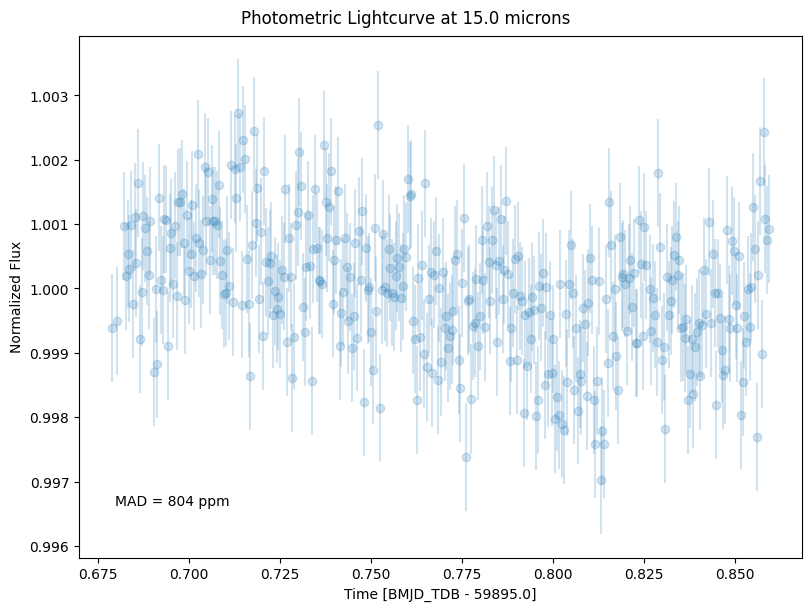

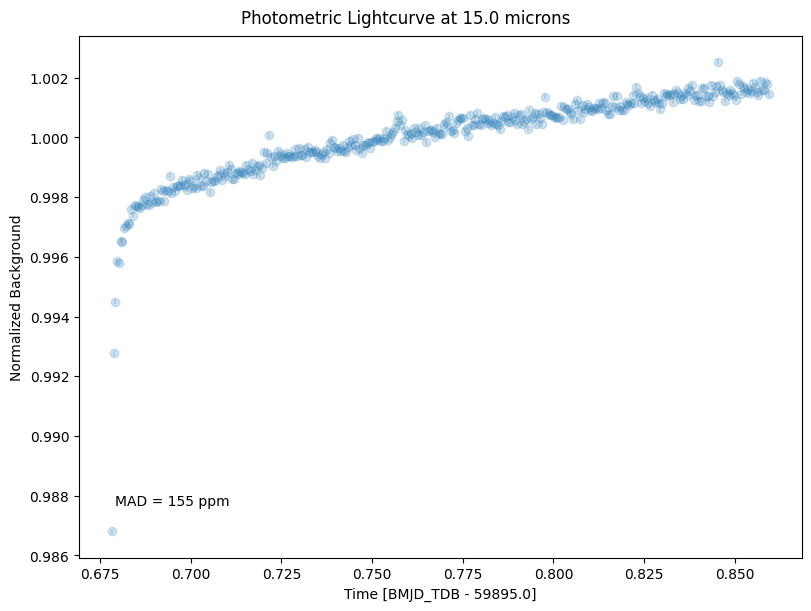

Saving results...
Finished writing to ../miri_photometry/Stage4/S4_2025-04-21_miri_photometry_run1/ap5_bg16_48/S4_miri_photometry_ap5_bg16_48_SpecData.h5
Finished writing to ../miri_photometry/Stage4/S4_2025-04-21_miri_photometry_run1/ap5_bg16_48/S4_miri_photometry_ap5_bg16_48_LCData.h5

Total time (min): 0.03


In [11]:
s4_spec, s4_lc, s4_meta = eureka.S4_generate_lightcurves.s4_genLC.genlc(eventlabel, ecf_path='./')

---
# Bonus: Getting the "best" reduction

Seeking the "best" reduction is where we venture into the art of data reduction, with various parameters sometimes having appreciable impacts on the precision we can get from our observations and (frighteningly) sometimes significantly impacting our final planetary spectra. At all times, think critically about the settings you are using and the potential for unintended consequences.

If you want to try to get even better results, focus on trying different values in Stage 3 for:

**Most impactful:**
*   `photap` (with a larger aperture you capture more of the star's light but also capture more noisy background light - there is a trade-off here which will likely change for every different target you observe)
*   `skyin` (with a smaller skyin you probe closer to the star but also more stellar contamination - there is a trade-off here which will likely change for every different target you observe)
*   `skywidth` (with a larger skywidth you average over more background pixels but you also probe less close to the star - there is a trade-off here which will likely change for every different target you observe)

**Uncertain impact:**
*   `bg_thresh` (you likely won't see large changes, but might slightly improve the overall scatter)
*   `interp_method` (similarly, you likely won't see large changes, but might slightly improve the overall scatter)
*   `aperture_edge` (the best value will likely normally be `'exact'`, but that may not always be the case)
*   `aperture_shape` (the best value will likely normally be `'circle'`, but that may not always be the case)

<br/>

Typically the "best" value for each parameter is independent of the values of other parameters, but sometimes there are interactions (e.g., in spectroscopic datasets a smaller `bg_hw` may require smaller `p3thresh`). The Stage 4 MAD (Median Absolute Deviation) value is an approximate tool you can use to determine how much your reduction has improved (typically the lower the value, the lower the noise in your lightcurve, and the "better" the reduction). A better indication of an improved reduction is the RMS of the residuals from your Stage 5 fit since the Stage 4 MAD doesn't account for noise that can be decorrelated when fitting, but depending on your dataset it can be prohibitively time-intensive to continuously run all reduction options through Stage 5.

Again though, remain critical and vigilant at all times when optimizing your reduction. For example, you'll be able to decrease your MAD value by setting your Stage 4 `sigma` value to `0.01`, but you're going to end up discarding nearly all of your data which you definitely don't want to do. A less obvious danger might be setting Stage 3's `bg_hw` parameter to too small a value, resulting in self-subtraction and potentially biased transit or eclipse depths.